In [259]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('ignore')

In [268]:
# data visualisation and manipulation 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from collections import Counter 
from sklearn.metrics import confusion_matrix 
from sklearn.utils import class_weight 
from imblearn.over_sampling import SMOTE
#dl libraraies

import tensorflow as tf 
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.applications.vgg16 import preprocess_input 
from keras.callbacks import EarlyStopping, ModelCheckpoint 

import os 
import tempfile 
from random import shuffle  
from PIL import Image 
# 
plt.rcParams['figure.figsize'] = (8, 6) 
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'] 

### Preparing data

In [269]:
dir = '../../dataset/task1'
train_dir = '../../dataset/task1/train'
val_dir = '../../dataset/task1/val'
test_dir = '../../dataset/task1/test'

BATCH = 32
HEIGHT = 224
WIDTH = 224
def load_data(path):
    ds = tf.keras.utils.image_dataset_from_directory(
        path,
        labels='inferred', #generate from directory structure
        label_mode = 'binary', #describing the encoding of labels
        class_names = ['seborrheic_keratosis', 'melanoma'],#Explicitly specify class order 0,1
        image_size = (HEIGHT, WIDTH),
        batch_size = BATCH,
    )
    return ds

In [270]:
train_data = load_data(train_dir)
val_data = load_data(val_dir)
test_data = load_data(test_dir)

Found 2000 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 600 files belonging to 2 classes.


In [240]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])
AUTOTUNE = tf.data.AUTOTUNE

def data_augment(data, shuffle=False, augment=False):
    norm = tf.keras.layers.Rescaling(1./255)
    ds = data.map(lambda x, y: (norm(x), y), num_parallel_calls = AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    #Augment only training
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training = True), y), 
                    num_parallel_calls = AUTOTUNE)
    return ds.prefetch(buffer_size = AUTOTUNE)

In [241]:
train_data = data_augment(train, shuffle=True, augment=True)
val_data = data_augment(val)
test_data = data_augment(test)

In [159]:
# total number of samples, positive/negative ratio 
labels_count = []
def sample_counts(data, train = False):
    total = 0 
    for images, labels in data:
        total += images.shape[0]
        if train:
            labels_count.append(labels.numpy())
    return total, labels_count

train_size, train_labels = sample_counts(train_data, train = True)
val_size, val_labels = sample_counts(val_data)
test_size, test_labels = sample_counts(test_data)

In [160]:
#number of +ve & -ve classes for initial bias
labels_flat = [label[0] for sublist in train_labels for label in sublist]
counts = Counter(labels_flat)
pos = counts[1] #melanoma 
neg = counts[0] #keratosis 
total = pos + neg
print('Total: {}\n Positive/Melanoma: {} ({:.2f}% of total)\n'.format(total, pos, 100 * pos / total))

weight_0 = (1/neg) * (total / 2.0)
weight_1 = (1/pos) * (total / 2.0)
class_weight = {0: weight_0, 1: weight_1}
print('Weight for class 0: {:.2f}'.format(weight_0))
print('Weight for class 1: {:.2f}'.format(weight_1))

Total: 2000
 Positive/Melanoma: 374 (18.70% of total)

Weight for class 0: 0.62
Weight for class 1: 2.67


### Feature Extraction

In [277]:
input_shape = (HEIGHT, WIDTH, 3)
input = tf.keras.layers.Input(shape = input_shape)
#Load the Convolutional part of VGG16
vgg_model = VGG16(weights = 'imagenet', include_top = False, input_tensor = input)
#vgg_model.summary()

In [162]:
def extraction(data, total_records):
    features = np.zeros(shape = (total_records, 7, 7, 512))
    labels = np.zeros(shape = (total_records, 1))
    i = 0
    for batch_images, batch_labels in data:
        batch_size = batch_images.shape[0]
        batch_features = vgg_model.predict(batch_images)
        features[i * BATCH : i  * BATCH + batch_size] = batch_features
        labels[i * BATCH: i * BATCH + batch_size] = batch_labels
        i += 1
        if i * BATCH >= total_records:
            break
        return features, labels

In [163]:
train_features, train_labels = extraction(train_data, train_size)
val_features, val_labels = extraction(val_data, val_size)
test_features, test_labels = extraction(test_data, test_size)

1/1 [==============================] - 3s 3s/step


In [164]:
train_features = np.reshape(train_features, (train_size, 7 * 7 * 512))
val_features = np.reshape(val_features, (val_size, 7 * 7 * 512))
test_features = np.reshape(test_features, (test_size, 7 * 7 * 512))

In [278]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.MeanSquaredError(name = 'MSE'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'accuracy'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]

In [226]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(units=1, activation = 'sigmoid'))

In [227]:
model.compile(
        optimizer = tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics = METRICS
    )

In [228]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    mode = 'min',
    restore_best_weights = True
)
history = model.fit(
    train_features,
    train_labels,
    epochs = 25,
    batch_size = BATCH,
    callbacks = [callback],
    validation_data = (val_features, val_labels),
    class_weight = class_weight,
    verbose = 2
)

Epoch 1/25
63/63 - 8s - loss: 0.8235 - Cross Entropy: 0.5705 - MSE: 0.0954 - TP: 0.0000e+00 - FP: 5.0000 - TN: 1990.0000 - FN: 5.0000 - accuracy: 0.9950 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.0050 - prc: 0.0013 - val_loss: 2.0667 - val_Cross Entropy: 2.0667 - val_MSE: 0.0545 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 142.0000 - val_FN: 8.0000 - val_accuracy: 0.9467 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.0845 - val_prc: 0.0288 - 8s/epoch - 135ms/step
Epoch 2/25
63/63 - 7s - loss: 0.0613 - Cross Entropy: 0.0517 - MSE: 0.0029 - TP: 3.0000 - FP: 4.0000 - TN: 1991.0000 - FN: 2.0000 - accuracy: 0.9970 - precision: 0.4286 - recall: 0.6000 - auc: 0.8240 - prc: 0.3937 - val_loss: 0.3872 - val_Cross Entropy: 0.3872 - val_MSE: 0.1128 - val_TP: 6.0000 - val_FP: 20.0000 - val_TN: 122.0000 - val_FN: 2.0000 - val_accuracy: 0.8533 - val_precision: 0.2308 - val_recall: 0.7500 - val_auc: 0.9137 - val_prc: 0.2373 - 7s/epoch - 112ms/step
Epoch 3/25
63/63 

In [229]:
def plot_loss(history, label, n):
    plt.semilogy(history.epoch, history.history['loss'],
                 color = colors[n], label = 'Train' + label)
    plt.semilogy(history.epoch, history.history['val_loss'],
                 color = colors[n], label = 'Val' + label,
                 linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

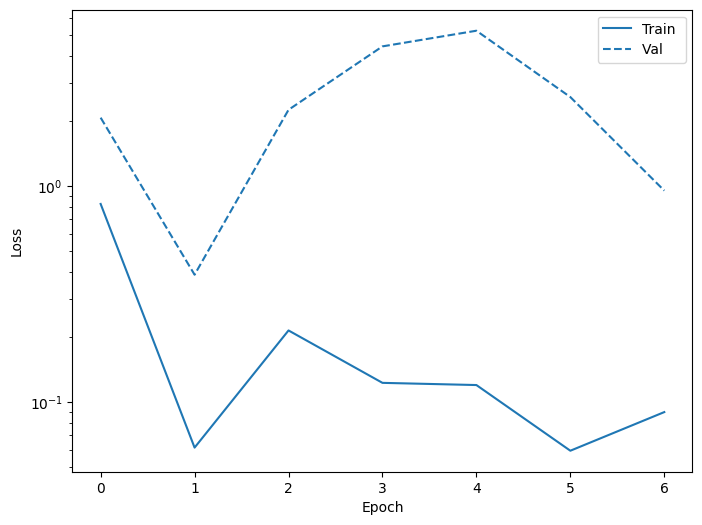

In [230]:
plot_loss(history, " ", 0)

In [231]:
#Plot Metrics
def plot_metrics(history):
    metrics = ['loss', 'prc', 'precision', 'recall']
    for n, metric in enumerate(metrics):
        name = metric.replace("_", " ").capitalize()
        plt.subplot(2,2, n+1)
        plt.plot(history.epoch, history.history[metric], color=colors[0], label='Train')
        plt.plot(history.epoch, history.history['val_'+metric],
        color=colors[0], linestyle='--', label='Val')
        plt.xlabel('Epoch')
        plt.ylabel(name)
        if metric == 'loss':
            plt.ylim([0, plt.ylim()[1]])
        elif metric == 'auc':
            plt.ylim(0.8, 1)
        else:
            plt.ylim([0, 1])
    plt.legend()

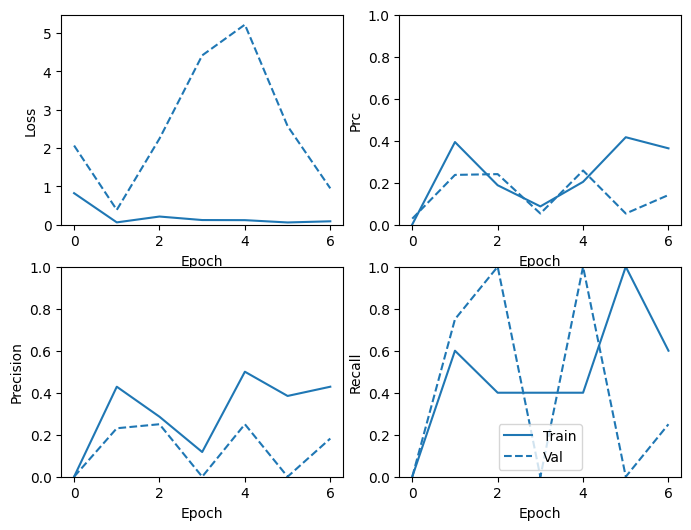

In [232]:
plot_metrics(history)

In [233]:
#train_prediction = model.predict(norm_train_data, batch_size = batch_size)
test_prediction = model.predict(test_features)

19/19 [==============================] - 1s 52ms/step


In [234]:
def plot_cm(labels, predictions, threshold= 0.5):
    cm = confusion_matrix(labels, predictions > threshold)
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title('Confusion matrix @{:.2f}'.format(threshold))
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')

    print('Keratosis (True Negatives): ', cm[0][0])
    print(' (False Positives):', cm[0][1])
    print('(False Negatives): ', cm[1][0])
    print(' Melanoma (True Positives):', cm[1][1])
    print('Total:', np.sum(cm[1]))
    

loss :  0.0
Cross Entropy :  0.0
MSE :  0.0
TP :  0.0
FP :  0.0
TN :  0.0
FN :  0.0
accuracy :  0.0
precision :  0.0
recall :  0.0
auc :  0.0
prc :  0.0

Keratosis (True Negatives):  570
 (False Positives): 23
(False Negatives):  1
 Melanoma (True Positives): 6
Total: 7


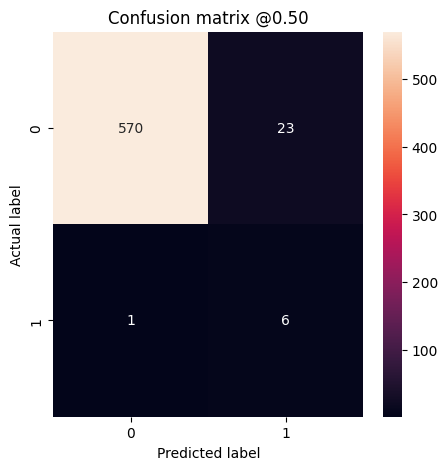

In [235]:
results = model.evaluate(test_features, verbose=0)
for name, value in zip(model.metrics_names, results):
    print(name, ': ', value)

print()
plot_cm(test_labels, test_prediction)

### Fine Tune
Based on the Confusion matrix the model is more bias towards the major class (keratosis)
Let's introduce class weight and if it doesn't help we should do oversampling of minor class

In [279]:
vgg_model.trainable = True
set_trainable = False
for layer in vgg_model.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

In [280]:
model = tf.keras.Sequential()
model.add(vgg_model)
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(units=512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(units=256, activation='relu'))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(units=1, activation = 'sigmoid'))

In [281]:
model.compile(
        optimizer = tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics = METRICS
    )

In [254]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    mode = 'min',
    restore_best_weights = True
)
history = model.fit(
    train_data,
    epochs = 25,
    batch_size = BATCH,
    callbacks = [callback],
    validation_data = (val_data),
    verbose = 2
)


Epoch 1/25
63/63 - 396s - loss: 0.5695 - Cross Entropy: 0.5695 - MSE: 0.1903 - TP: 0.0000e+00 - FP: 6.0000 - TN: 1620.0000 - FN: 374.0000 - accuracy: 0.8100 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.4707 - prc: 0.1766 - val_loss: 0.5005 - val_Cross Entropy: 0.5005 - val_MSE: 0.1600 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_accuracy: 0.8000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5000 - val_prc: 0.2000 - 396s/epoch - 6s/step
Epoch 2/25
63/63 - 343s - loss: 0.4889 - Cross Entropy: 0.4889 - MSE: 0.1544 - TP: 0.0000e+00 - FP: 0.0000e+00 - TN: 1626.0000 - FN: 374.0000 - accuracy: 0.8130 - precision: 0.0000e+00 - recall: 0.0000e+00 - auc: 0.4879 - prc: 0.1793 - val_loss: 0.5007 - val_Cross Entropy: 0.5007 - val_MSE: 0.1601 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_accuracy: 0.8000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5000 - val_prc: 0.2000 -

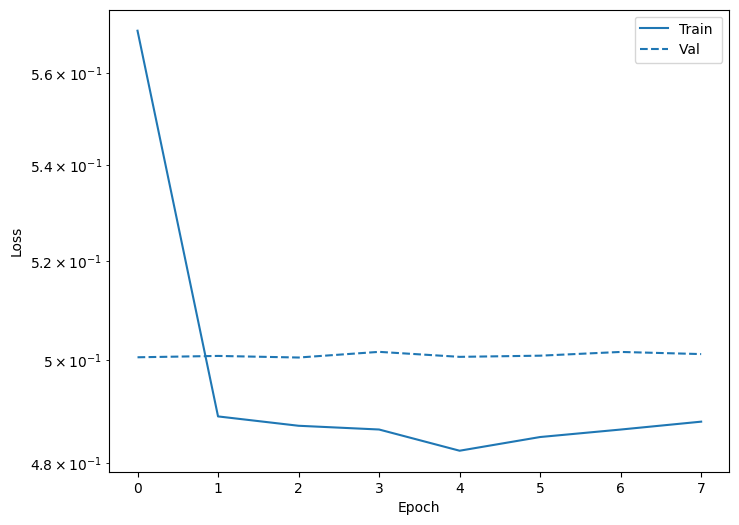

In [255]:
plot_loss(history, " ", 0) 

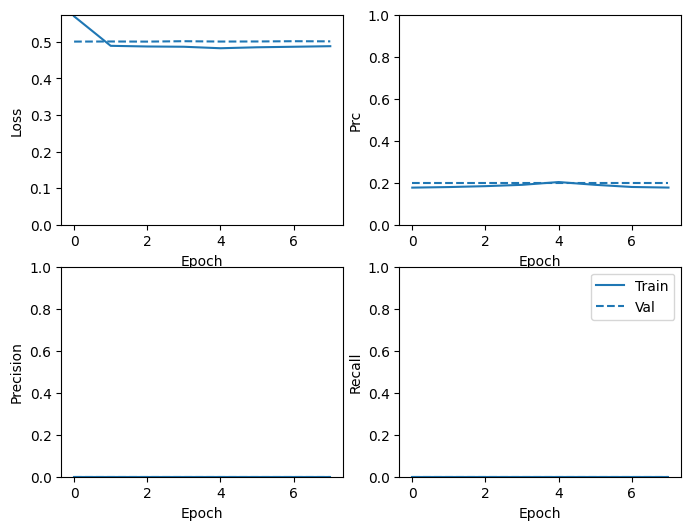

In [256]:
plot_metrics(history)

In [257]:
test_prediction = model.predict(test_data) 

19/19 [==============================] - 172s 8s/step


loss :  0.4934218227863312
Cross Entropy :  0.4934218227863312
MSE :  0.1569843739271164
TP :  0.0
FP :  0.0
TN :  483.0
FN :  117.0
accuracy :  0.8050000071525574
precision :  0.0
recall :  0.0
auc :  0.5
prc :  0.19499999284744263

Keratosis (True Negatives):  593
 (False Positives): 0
(False Negatives):  7
 Melanoma (True Positives): 0
Total: 7


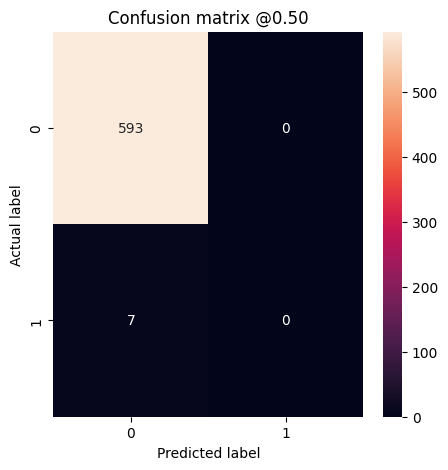

In [258]:
results = model.evaluate(test_data, verbose=0) 
for name, value in zip(model.metrics_names, results): 
    print(name, ': ', value) 

print() 
plot_cm(test_labels, test_prediction) 

### Resampling

In [271]:
def data_to_numpy(data):
    images = []
    labels = []
    for batch in data:
        images.append(batch[0].numpy())
        labels.append(batch[1].numpy())
    return np.concatenate(images), np.concatenate(labels)
x_train, y_train = data_to_numpy(train_data)
#reshape input
x_train = x_train.reshape((-1, HEIGHT * WIDTH * 3))

In [272]:
#APPLY SMOTE 
smote = SMOTE(random_state = 100) 
x_resampled , y_resampled = smote.fit_resample(x_train, y_train)
x_resampled = x_resampled.reshape((-1, HEIGHT, WIDTH, 3)) 

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    mode = 'min',
    restore_best_weights = True
)
history = model.fit(
    x_resampled,
    y_resampled,
    epochs = 25,
    batch_size = BATCH,
    callbacks = [callback],
    validation_data = (val_data),
    verbose = 2
)


Epoch 1/25
102/102 - 1100s - loss: 1.2765 - Cross Entropy: 1.2765 - MSE: 0.2873 - TP: 1171.0000 - FP: 1175.0000 - TN: 451.0000 - FN: 455.0000 - accuracy: 0.4988 - precision: 0.4991 - recall: 0.7202 - auc: 0.4982 - prc: 0.4981 - val_loss: 0.6933 - val_Cross Entropy: 0.6933 - val_MSE: 0.2501 - val_TP: 30.0000 - val_FP: 120.0000 - val_TN: 0.0000e+00 - val_FN: 0.0000e+00 - val_accuracy: 0.2000 - val_precision: 0.2000 - val_recall: 1.0000 - val_auc: 0.5000 - val_prc: 0.2000 - 1100s/epoch - 11s/step
Epoch 2/25
102/102 - 1115s - loss: 0.6932 - Cross Entropy: 0.6932 - MSE: 0.2500 - TP: 1342.0000 - FP: 1343.0000 - TN: 283.0000 - FN: 284.0000 - accuracy: 0.4997 - precision: 0.4998 - recall: 0.8253 - auc: 0.4982 - prc: 0.5006 - val_loss: 0.6848 - val_Cross Entropy: 0.6848 - val_MSE: 0.2458 - val_TP: 0.0000e+00 - val_FP: 0.0000e+00 - val_TN: 120.0000 - val_FN: 30.0000 - val_accuracy: 0.8000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.5000 - val_prc: 0.2000 - 1115s/epoch - 11s